# From Silence to Surge: Modeling Zero-Inflated Dengue Outbreaks in Bangladesh

Code for the paper accepted at the **12th IEEE International Women in Engineering (WIE) Conference on Electrical and Computer Engineering (WIECON-ECE 2026)**.

**Paper:** _link to be added after publication (IEEE Xplore / DOI)_

**Code and dataset:** https://github.com/marufbangabashi/Dengue-D-79-

**Authors:** Md. Maruf Bangabashi, Md. Mostafijur Rahman, Jihadul Islam Rifat, Jhoton Chandra Nath, Nusrat Sorna, Most Jannatun Ferdous Jim. Department of Computer Science and Engineering, Dhaka International University, Dhaka, Bangladesh.

---
## What this notebook does
It generates, from the daily division-level dataset (`Dataset.csv`), the experiments reported in the paper:

| Paper item | Section of this notebook |
|---|---|
| Dataset statistics (Section III) | 2 |
| Unified features and walk-forward folds (Section IV-B, IV-C) | 3 |
| Table III: 3-fold benchmark, ten models | 4 to 5 |
| Paired t-tests and hurdle-stage AUC (Section V-A, V-B) | 6 |
| Table IV: SMAPE on zero vs. positive days | 7 |
| Table V and outbreak-day rows by division | 8 |
| Figs. 4 and 5 | 9 |
| Check against the numbers printed in the paper | 10 |

The preliminary ANN/LSTM/XGBoost/RF/etc. notebooks (Table II) are separate and are not part of this one.

## How to run
1. Put `Dataset.csv` (columns `date, division, Patients, max temp, min temp, rainfall, humidity`) next to this notebook, or set the `DENGUE_CSV` environment variable.
2. Run all cells (about 30 seconds on a laptop CPU).

**Library versions matter.** The XGBoost results depend on the library version: the paper uses `xgboost==3.1.3`. Other XGBoost releases give different numbers for the two XGBoost models (the other eight models are unaffected).

## 1. Setup

In [1]:
# Pinned version used in the paper (XGBoost results depend on it).
%pip install -q "xgboost==3.1.3" lightgbm catboost scikit-learn scipy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import sklearn, xgboost, lightgbm, catboost, scipy
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, roc_auc_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor

print("xgboost", xgboost.__version__, "| lightgbm", lightgbm.__version__, "| catboost", catboost.__version__,
      "| scikit-learn", sklearn.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)
if xgboost.__version__ != "3.1.3":
    print("WARNING: the paper uses xgboost 3.1.3; XGBoost / XGBoost-Tweedie numbers will differ with another version.")

RNG = 42
N_FOLDS = 3
CANDIDATES = [os.environ.get("DENGUE_CSV", ""), "Dataset.csv", "data/Dataset.csv", "../Dataset.csv",
              "/kaggle/input/dengue-bangladesh/Dataset.csv", "/content/Dataset.csv"]
DATA_PATH = next((p for p in CANDIDATES if p and os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("Dataset.csv not found. Place it next to this notebook or set DENGUE_CSV.")
os.makedirs("figures", exist_ok=True)
print("Using", DATA_PATH)

xgboost 3.1.3 | lightgbm 4.7.0 | catboost 1.2.10 | scikit-learn 1.9.1 | numpy 2.5.3 | pandas 3.0.5
Using Dataset.csv


## 2. Dataset and target distribution (paper Section III)

In [3]:
raw = pd.read_csv(DATA_PATH)
raw["date"] = pd.to_datetime(raw["date"], format="%m/%d/%Y")
p = raw["Patients"]
print(f"rows: {len(raw):,} | divisions: {raw.division.nunique()} | days per division: {raw.groupby('division').size().unique()}")
print(f"date range: {raw.date.min().date()} to {raw.date.max().date()}")
print(f"zero share: {(p == 0).mean():.3%} | mean: {p.mean():.2f} | SD: {p.std():.2f} | median: {p.median():.0f} | max: {p.max()}")
print(f"variance-to-mean ratio: {p.var() / p.mean():.1f}  (Poisson would give 1)")
raw.groupby("division").Patients.agg(mean="mean", zero_share=lambda s: (s == 0).mean(), max="max").round(2)

rows: 11,200 | divisions: 8 | days per division: [1400]
date range: 2022-01-01 to 2025-10-31
zero share: 42.286% | mean: 49.42 | SD: 152.75 | median: 2 | max: 1703
variance-to-mean ratio: 472.2  (Poisson would give 1)


,mean,zero_share,max
division,,,
Barishal,47.81,0.31,477
Chattogram,56.81,0.21,547
Dhaka,214.95,0.07,1703
Khulna,36.87,0.41,436
Mymensingh,10.39,0.45,105
Rajshahi,21.27,0.53,246
Rangpur,5.74,0.68,88
Sylhet,1.52,0.73,30


## 3. Unified features and walk-forward folds (Sections IV-B, IV-C)
All lag and rolling features are computed inside each division from past values only. The first 14 days of each division have no complete rolling window and are dropped (11,200 → 11,088 division-days). Fold *k* (k = 0, 1, 2) trains on the first (60 + 10k)% of each division and tests on the next 10%.

In [4]:
df = raw.sort_values(["division", "date"]).reset_index(drop=True)
df["year"] = df.date.dt.year
df["month"] = df.date.dt.month
df["week"] = df.date.dt.isocalendar().week.astype(int)
df["doy"] = df.date.dt.dayofyear
df["division_code"] = df.division.map({d: i for i, d in enumerate(sorted(df.division.unique()))})
g = df.groupby("division")["Patients"]
df["lag_1"] = g.shift(1)
df["lag_7"] = g.shift(7)
df["roll_mean_7"] = g.shift(1).rolling(7).mean().reset_index(level=0, drop=True)
df["roll_mean_14"] = g.shift(1).rolling(14).mean().reset_index(level=0, drop=True)
df = df.dropna().reset_index(drop=True)
FEATURES = ["division_code", "year", "month", "week", "doy", "max temp", "min temp", "rainfall", "humidity",
            "lag_1", "lag_7", "roll_mean_7", "roll_mean_14"]
TARGET = "Patients"
print("division-days used for modeling:", len(df))

fold_indices = [[] for _ in range(N_FOLDS)]
for d, sub in df.groupby("division"):
    n = len(sub)
    for k in range(N_FOLDS):
        a, b = int(n * (0.6 + 0.1 * k)), int(n * (0.6 + 0.1 * (k + 1)))
        fold_indices[k].append((sub.index[:a], sub.index[a:b]))

division-days used for modeling: 11088


## 4. Metrics
* **MAE** overall and on **outbreak days** (top decile of the test fold's counts; the threshold differs by fold).
* **SMAPE** = 100·mean(|y−ŷ| / (|y|+|ŷ|)), with 0/0 counted as 0 and predictions clipped at zero. SMAPE replaces MAPE, which explodes at y = 0, but it has its own zero-day behaviour (Section 7).

In [5]:
def smape_terms(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    den = np.abs(y) + np.abs(p)
    return 100 * np.where(den == 0, 0.0, np.abs(y - p) / np.where(den == 0, 1, den))

MODELS = ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost", "LightGBM", "CatBoost", "ANN/MLP",
          "XGBoost-Tweedie", "LightGBM-Tweedie", "Hurdle (2-stage)"]
ZI_AWARE = ["XGBoost-Tweedie", "LightGBM-Tweedie", "Hurdle (2-stage)"]

def make_models():
    return {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=RNG),
        "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=RNG, n_jobs=-1),
        "XGBoost": XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=RNG, n_jobs=-1),
        "LightGBM": LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=RNG, verbosity=-1),
        "CatBoost": CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05, loss_function="RMSE", random_seed=RNG, verbose=False),
        "ANN/MLP": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=400, random_state=RNG, early_stopping=True),
        "XGBoost-Tweedie": XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=RNG,
                                        objective="reg:tweedie", tweedie_variance_power=1.3, n_jobs=-1),
        "LightGBM-Tweedie": LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=RNG,
                                          objective="tweedie", tweedie_variance_power=1.3, verbosity=-1),
    }

## 5. Run the benchmark (Table III)

In [6]:
records, fold_info, hurdle_auc = [], [], []
fold_overall = {m: [] for m in MODELS}; fold_outbreak = {m: [] for m in MODELS}; fold_smape = {m: [] for m in MODELS}

for k in range(N_FOLDS):
    tr = np.concatenate([a for a, b in fold_indices[k]]); te = np.concatenate([b for a, b in fold_indices[k]])
    Xtr, ytr, Xte, yte = df.loc[tr, FEATURES], df.loc[tr, TARGET], df.loc[te, FEATURES], df.loc[te, TARGET].values
    thr = np.quantile(yte, 0.90); ob = yte >= thr
    fold_info.append(dict(fold=k, n_train=len(tr), n_test=len(te), outbreak_threshold=round(float(thr), 1),
                          n_outbreak_rows=int(ob.sum()), zero_share_test=round(float((yte == 0).mean()), 3)))
    preds = {name: m.fit(Xtr, ytr).predict(Xte) for name, m in make_models().items()}
    # two-stage hurdle: P(Patients>0) x E[Patients | Patients>0] (stage 2 regresses log1p on positive days only)
    clf = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=RNG, verbosity=-1).fit(Xtr, (ytr > 0).astype(int))
    proba = clf.predict_proba(Xte)[:, 1]
    hurdle_auc.append(roc_auc_score((yte > 0).astype(int), proba))
    pos = (ytr > 0).values
    reg = LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=RNG, verbosity=-1).fit(Xtr[pos], np.log1p(ytr[pos]))
    preds["Hurdle (2-stage)"] = proba * np.clip(np.expm1(reg.predict(Xte)), 0, None)
    div = df.loc[te, "division"].values
    for m in MODELS:
        pc = np.clip(np.asarray(preds[m]), 0, None)
        fold_overall[m].append(mean_absolute_error(yte, pc))
        fold_outbreak[m].append(mean_absolute_error(yte[ob], pc[ob]))
        fold_smape[m].append(smape_terms(yte, pc).mean())
        records.append(pd.DataFrame({"fold": k, "model": m, "division": div, "y": yte, "p": pc, "ob": ob}))
    print("fold", k, "done")
pred = pd.concat(records, ignore_index=True)
pd.DataFrame(fold_info)

fold 0 done


fold 1 done


fold 2 done


,fold,n_train,n_test,outbreak_threshold,n_outbreak_rows,zero_share_test
0,0,6648,1112,38.9,112,0.438
1,1,7760,1104,165.4,111,0.116
2,2,8864,1112,11.0,124,0.540


In [7]:
table3 = pd.DataFrame({
    "Overall MAE": [f"{np.mean(fold_overall[m]):.2f} ± {np.std(fold_overall[m]):.2f}" for m in MODELS],
    "Outbreak MAE": [f"{np.mean(fold_outbreak[m]):.2f} ± {np.std(fold_outbreak[m]):.2f}" for m in MODELS],
    "SMAPE": [f"{np.mean(fold_smape[m]):.1f}" for m in MODELS]}, index=MODELS)
table3.index.name = "Table III"
table3

,Overall MAE,Outbreak MAE,SMAPE
Table III,,,
Linear Regression,9.84 ± 6.50,39.67 ± 30.74,47.6
Decision Tree,11.07 ± 8.95,52.75 ± 46.76,54.5
Random Forest,8.97 ± 6.53,37.13 ± 28.72,52.7
XGBoost,9.52 ± 7.57,45.12 ± 39.24,52.5
LightGBM,9.01 ± 6.81,40.03 ± 32.25,51.8
CatBoost,9.29 ± 6.64,38.24 ± 29.98,51.6
ANN/MLP,10.50 ± 7.88,41.47 ± 33.17,45.9
XGBoost-Tweedie,8.71 ± 6.52,37.95 ± 29.50,53.2
LightGBM-Tweedie,8.83 ± 6.64,37.76 ± 29.07,53.1


## 6. Paired t-tests and hurdle-stage AUC (Sections V-A, V-B)
Paired t-tests across the three folds' outbreak-day MAE, each zero-inflation-aware model against the best conventional baseline. With 3 folds (2 degrees of freedom) these tests are underpowered. A negative *t* means the zero-inflation-aware model is worse than the baseline.

In [8]:
plain = [m for m in MODELS if m not in ZI_AWARE]
best_plain = min(plain, key=lambda m: np.mean(fold_outbreak[m]))
print("best conventional baseline on outbreak days:", best_plain)
for m in ZI_AWARE:
    t, pv = stats.ttest_rel(fold_outbreak[best_plain], fold_outbreak[m])
    print(f"{m:18s} vs {best_plain}: t = {t:+.2f}, p = {pv:.3f}")
print("hurdle occurrence AUC per fold:", [round(a, 3) for a in hurdle_auc])
print("per-fold outbreak MAE:", {m: [round(v, 2) for v in fold_outbreak[m]] for m in [best_plain] + ZI_AWARE})

best conventional baseline on outbreak days: Random Forest
XGBoost-Tweedie    vs Random Forest: t = -1.40, p = 0.296
LightGBM-Tweedie   vs Random Forest: t = -1.96, p = 0.190
Hurdle (2-stage)   vs Random Forest: t = -1.17, p = 0.362
hurdle occurrence AUC per fold: [0.886, 0.933, 0.891]
per-fold outbreak MAE: {'Random Forest': [24.17, 76.95, 10.26], 'XGBoost-Tweedie': [25.02, 78.76, 10.06], 'LightGBM-Tweedie': [25.05, 77.97, 10.26], 'Hurdle (2-stage)': [25.55, 92.15, 10.54]}


## 7. SMAPE on zero days vs. positive days (Table IV)
A true-zero day with any positive prediction scores exactly 100% whatever its size, while an exactly-zero prediction scores 0. Models that never predict exactly zero therefore score 100% on every zero day.

In [9]:
pred["smape"] = smape_terms(pred.y.values, pred.p.values)
pred["zero"] = pred.y == 0
t4 = pred.groupby(["model", "zero"]).smape.mean().unstack().rename(columns={True: "Zero days", False: "Positive days"})
t4["share of zero days predicted exactly 0"] = pred[pred.zero].groupby("model").p.apply(lambda s: (s == 0).mean())
print(f"zero days: {pred[pred.model == 'Random Forest'].zero.mean():.1%} of pooled test rows")
t4 = t4.loc[MODELS].round(3); t4.index.name = "Table IV (pooled over folds)"; t4

zero days: 36.5% of pooled test rows


zero,Positive days,Zero days,share of zero days predicted exactly 0
Table IV (pooled over folds),,,
Linear Regression,30.225,77.942,0.221
Decision Tree,28.342,100.000,0.000
Random Forest,25.517,100.000,0.000
XGBoost,25.711,99.177,0.008
LightGBM,24.511,99.506,0.005
CatBoost,27.518,93.580,0.064
ANN/MLP,42.258,52.181,0.478
XGBoost-Tweedie,26.354,100.000,0.000
LightGBM-Tweedie,26.200,100.000,0.000


## 8. Per-division error (Table V) and outbreak-day rows

In [10]:
pred["ae"] = (pred.y - pred.p).abs()
per_div = pred.groupby(["model", "division", "fold"]).ae.mean().groupby(["model", "division"]).mean().unstack(0)
base = pred[pred.model == "Random Forest"].groupby("division").agg(mean_cases=("y", "mean"), pct_zero=("y", lambda s: 100 * (s == 0).mean()))
t5 = base.join(per_div[["Random Forest", "XGBoost-Tweedie", "LightGBM-Tweedie", "Hurdle (2-stage)"]]).round(2)
t5.index.name = "Table V (mean of 3 folds)"
display(t5)
rf = pred[(pred.model == "Random Forest") & pred.ob]
print("outbreak-day rows by division:", rf.groupby("division").size().to_dict(), "| total:", len(rf))
ob_div = pred[pred.ob].groupby(["model", "division", "fold"]).ae.mean().groupby(["model", "division"]).mean().unstack(0)
ob_div[["Random Forest", "XGBoost-Tweedie", "LightGBM-Tweedie", "Hurdle (2-stage)"]].round(1)

,mean_cases,pct_zero,Random Forest,XGBoost-Tweedie,LightGBM-Tweedie,Hurdle (2-stage)
Table V (mean of 3 folds),,,,,,
Barishal,26.31,14.66,11.48,10.26,10.18,10.36
Chattogram,38.13,10.34,15.52,15.13,15.80,14.78
Dhaka,142.84,0.48,27.38,27.48,27.85,30.54
Khulna,24.31,31.73,7.37,7.21,7.29,7.19
Mymensingh,7.58,39.18,2.78,2.66,2.72,2.80
Rajshahi,9.57,50.72,4.12,4.13,4.01,4.26
Rangpur,3.64,68.99,2.25,2.07,2.09,2.11
Sylhet,0.85,75.96,0.85,0.71,0.72,0.74


outbreak-day rows by division: {'Barishal': 60, 'Chattogram': 78, 'Dhaka': 199, 'Khulna': 10} | total: 347


model,Random Forest,XGBoost-Tweedie,LightGBM-Tweedie,Hurdle (2-stage)
division,,,,
Barishal,24.2,24.0,23.0,23.3
Chattogram,28.6,29.1,27.6,32.7
Dhaka,37.9,38.6,38.8,43.8
Khulna,19.7,22.4,19.6,25.8


## 9. Figures 4 and 5

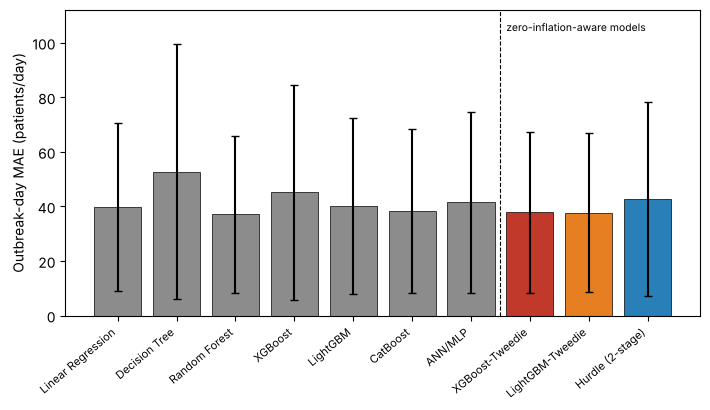

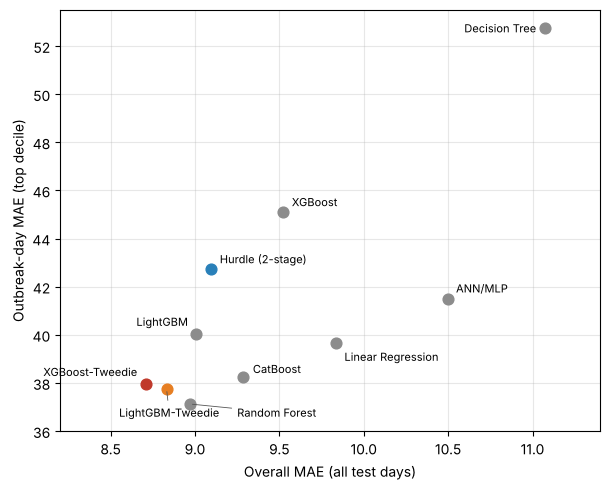

In [11]:
S = {m: dict(o=np.mean(fold_overall[m]), ob=np.mean(fold_outbreak[m]), sd=np.std(fold_outbreak[m])) for m in MODELS}
col = ["#8c8c8c"] * 7 + ["#c0392b", "#e67e22", "#2980b9"]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(range(10), [S[m]["ob"] for m in MODELS], yerr=[S[m]["sd"] for m in MODELS], capsize=3, color=col, edgecolor="black", linewidth=0.5)
ax.set_xticks(range(10)); ax.set_xticklabels(MODELS, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Outbreak-day MAE (patients/day)"); ax.set_ylim(0, 112)
ax.axvline(6.5, color="black", ls="--", lw=0.8); ax.text(6.6, 108, "zero-inflation-aware models", fontsize=7.5, va="top")
plt.tight_layout(); plt.savefig("figures/Fig4_outbreak_mae.png", dpi=300); plt.show()

off = {"Linear Regression": (6, -13, "left"), "Decision Tree": (-6, -3, "right"), "XGBoost": (6, 4, "left"), "LightGBM": (-6, 6, "right"),
       "CatBoost": (7, 3, "left"), "ANN/MLP": (6, 5, "left"), "XGBoost-Tweedie": (-6, 6, "right"), "Hurdle (2-stage)": (6, 4, "left")}
fig, ax = plt.subplots(figsize=(6.2, 5))
for i, m in enumerate(MODELS):
    x, y = S[m]["o"], S[m]["ob"]; ax.scatter(x, y, color=col[i], s=60, zorder=3)
    if m == "LightGBM-Tweedie": ax.annotate(m, (x, y), fontsize=8, xytext=(8.55, 36.6), arrowprops=dict(arrowstyle="-", lw=.6, color="#555"))
    elif m == "Random Forest": ax.annotate(m, (x, y), fontsize=8, xytext=(9.25, 36.6), arrowprops=dict(arrowstyle="-", lw=.6, color="#555"))
    else:
        dx, dy, ha = off[m]; ax.annotate(m, (x, y), fontsize=8, xytext=(dx, dy), textcoords="offset points", ha=ha)
ax.set_xlim(8.2, 11.4); ax.set_ylim(36, 53.5); ax.grid(alpha=.3)
ax.set_xlabel("Overall MAE (all test days)"); ax.set_ylabel("Outbreak-day MAE (top decile)")
plt.tight_layout(); plt.savefig("figures/Fig5_overall_vs_outbreak.png", dpi=300); plt.show()

## 10. Check against the numbers printed in the paper
Differences larger than 0.01 usually mean a different library version (most often XGBoost).

In [12]:
paper = {  # model: (overall MAE, outbreak MAE) as in Table III of the paper
 "Linear Regression": (9.84, 39.67), "Decision Tree": (11.07, 52.75), "Random Forest": (8.97, 37.13),
 "XGBoost": (9.52, 45.12), "LightGBM": (9.01, 40.03), "CatBoost": (9.29, 38.24), "ANN/MLP": (10.50, 41.47),
 "XGBoost-Tweedie": (8.71, 37.95), "LightGBM-Tweedie": (8.83, 37.76), "Hurdle (2-stage)": (9.10, 42.75)}
rows = []
for m, (po, pob) in paper.items():
    o, ob_ = np.mean(fold_overall[m]), np.mean(fold_outbreak[m])
    rows.append((m, po, round(o, 2), pob, round(ob_, 2), "OK" if abs(o - po) < 0.011 and abs(ob_ - pob) < 0.011 else "DIFFERS"))
chk = pd.DataFrame(rows, columns=["model", "paper overall", "this run", "paper outbreak", "this run ", "status"]).set_index("model")
chk

,paper overall,this run,paper outbreak,this run,status
model,,,,,
Linear Regression,9.84,9.84,39.67,39.67,OK
Decision Tree,11.07,11.07,52.75,52.75,OK
Random Forest,8.97,8.97,37.13,37.13,OK
XGBoost,9.52,9.52,45.12,45.12,OK
LightGBM,9.01,9.01,40.03,40.03,OK
CatBoost,9.29,9.29,38.24,38.24,OK
ANN/MLP,10.50,10.50,41.47,41.47,OK
XGBoost-Tweedie,8.71,8.71,37.95,37.95,OK
LightGBM-Tweedie,8.83,8.83,37.76,37.76,OK


## 11. Save results

In [13]:
out = {"versions": {"xgboost": xgboost.__version__, "lightgbm": lightgbm.__version__, "catboost": catboost.__version__,
                    "scikit-learn": sklearn.__version__},
       "fold_info": fold_info, "hurdle_auc_per_fold": hurdle_auc,
       "summary": {m: dict(overall_mean=float(np.mean(fold_overall[m])), overall_std=float(np.std(fold_overall[m])),
                           outbreak_mean=float(np.mean(fold_outbreak[m])), outbreak_std=float(np.std(fold_outbreak[m])),
                           smape_mean=float(np.mean(fold_smape[m])), fold_outbreak=fold_outbreak[m], fold_overall=fold_overall[m])
                   for m in MODELS}}
json.dump(out, open("results_cv_notebook.json", "w"), indent=2)
table3.to_csv("table3.csv"); t4.to_csv("table4.csv"); t5.to_csv("table5.csv")
print("saved results_cv_notebook.json, table3.csv, table4.csv, table5.csv, figures/")

saved results_cv_notebook.json, table3.csv, table4.csv, table5.csv, figures/
